<a href="https://colab.research.google.com/github/Abel-Jacob/MNIST-overfitting-analysis/blob/main/MNIST_Overfitting_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Overfitting and Regularization Analysis

## Introduction
For this task, I wanted to explore how and why neural networks overfit on training data, and how to fix it using regularization. I used the classic MNIST handwritten digits dataset and built a Convolutional Neural Network (CNN).

To see overfitting in action, I split the project into two main experiments:
1. Part A: I trained a large CNN with absolutely no regularization. Since the model is way bigger than it needs to be for this dataset, it should easily memorize the training images and fail to generalize.
2. Part B: I trained the exact same model architecture, but added training-time adjustments like data augmentation, weight decay, early stopping, and learning rate scheduling to see if they prevent the model from overfitting.

Finally, I compared both runs side-by-side using validation curves, test set scores, and confusion matrices.

## 1. Importing Libraries and Device Selection

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset, ConcatDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import copy
import itertools
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import seaborn as sns

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch Version: {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
PyTorch Version: 2.11.0+cu128
GPU: Tesla T4


## 2. Dataset Split and Preprocessing

To construct the dataset splits, I merged all 70,000 samples (60,000 training and 10,000 test) into a single pool. From this pool, I performed a stratified split to divide the images into:
- 70% for training (49,000 images)
- 15% for validation (10,500 images)
- 15% for testing (10,500 images)

The stratified split ensures that each of the three subsets maintains an identical proportion of the 10 digit classes. I normalized all images using the standard MNIST mean (0.1307) and standard deviation (0.3081).

In [3]:
# Preprocessing transform
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download dataset parts and merge them
train_dataset_std = datasets.MNIST(root='./data', train=True, download=True, transform=basic_transform)
test_dataset_std = datasets.MNIST(root='./data', train=False, download=True, transform=basic_transform)
full_dataset_std = ConcatDataset([train_dataset_std, test_dataset_std])

# Extract labels for stratified split
all_targets = torch.cat([train_dataset_std.targets, test_dataset_std.targets]).numpy()

# Perform stratified splits (70% train, 30% val+test)
indices = np.arange(len(all_targets))
train_idx, val_test_idx = train_test_split(
    indices, test_size=0.3, stratify=all_targets, random_state=42
)

# Split val+test into validation (15% total) and testing (15% total)
val_test_targets = all_targets[val_test_idx]
val_idx, test_idx = train_test_split(
    val_test_idx, test_size=0.5, stratify=val_test_targets, random_state=42
)

train_set = Subset(full_dataset_std, train_idx)
val_set = Subset(full_dataset_std, val_idx)
test_set = Subset(full_dataset_std, test_idx)

BATCH_SIZE = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=0)

print(f"Training set: {len(train_set)} images")
print(f"Validation set: {len(val_set)} images")
print(f"Test set: {len(test_set)} images")
print(f"Image shape: {full_dataset_std[0][0].shape} (C, H, W)")

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]

Training set: 49000 images
Validation set: 10500 images
Test set: 10500 images
Image shape: torch.Size([1, 28, 28]) (C, H, W)


## 3. Visualizing the Data

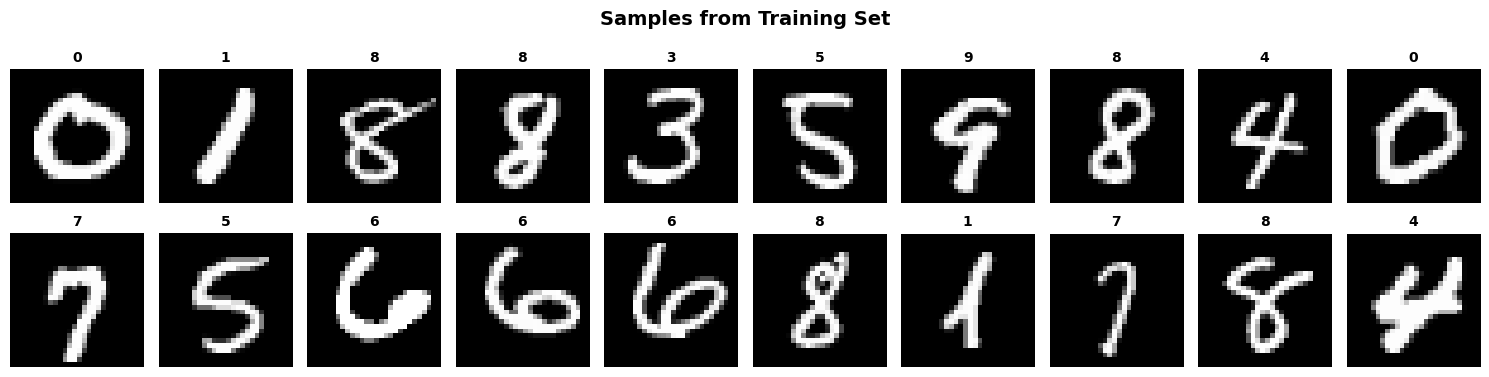

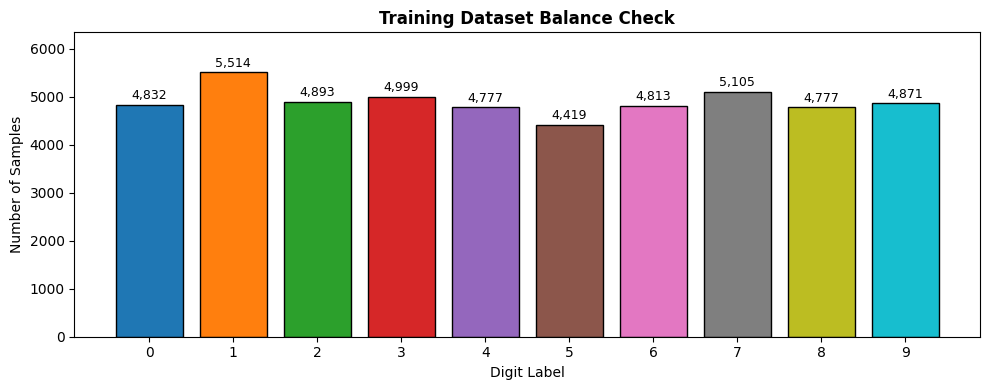

In [4]:
# Plot some sample images
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(20):
    ax = axes[i // 10, i % 10]
    image, label = train_set[i]
    raw_img = (image.squeeze() * 0.3081 + 0.1307).numpy()
    ax.imshow(raw_img, cmap='gray')
    ax.set_title(str(label), fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle("Samples from Training Set", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot the distribution of classes in train split
train_labels = all_targets[train_idx]
classes, frequency = np.unique(train_labels, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(classes, frequency, color=plt.cm.tab10(np.arange(10)), edgecolor='black')
ax.set_xlabel("Digit Label")
ax.set_ylabel("Number of Samples")
ax.set_title("Training Dataset Balance Check", fontsize=12, fontweight='bold')
ax.set_xticks(range(10))


ax.set_ylim(0, max(frequency) * 1.15)

for bar, val in zip(bars, frequency):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f"{val:,}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Designing the Overfit Model

To force the model to overfit, I built a large Convolutional Neural Network (CNN) with 6 convolutional layers and 4 fully connected layers. This model contains over 4.16 million trainable parameters, which is way too much capacity for simple 28x28 grayscale digits.

By default, I did not include any dropout or batch normalization layers because I want to see if the model starts to memorize the data.

In [5]:
class ExperimentalCNN(nn.Module):
    def __init__(self):
        super(ExperimentalCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 3 * 3, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Display the model parameters
test_model = ExperimentalCNN().to(device)
param_count = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"Total parameters: {param_count:,}")
print(f"Parameters per training sample: {param_count / len(train_set):.2f}")
del test_model

Total parameters: 4,163,274
Parameters per training sample: 84.96


## 5. Helper Functions for Training and Evaluation

In [6]:
def run_single_epoch(model, loader, loss_fn, opt, dev, epoch_idx, total_epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    # Wrap loop with tqdm loading bar
    progress_bar = tqdm(
        loader,
        desc=f"Epoch {epoch_idx+1:02d}/{total_epochs}",
        leave=False
    )
    for inputs, targets in progress_bar:
        inputs, targets = inputs.to(dev), targets.to(dev)

        opt.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)
        loss.backward()
        opt.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct_preds += preds.eq(targets).sum().item()
        total_samples += targets.size(0)

        # Display running batch metrics on the bar
        current_acc = 100.0 * correct_preds / total_samples
        progress_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_acc:.2f}%")

    return running_loss / total_samples, 100.0 * correct_preds / total_samples

def evaluate_performance(model, loader, loss_fn, dev):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(dev), targets.to(dev)
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct_preds += preds.eq(targets).sum().item()
            total_samples += targets.size(0)

    return running_loss / total_samples, 100.0 * correct_preds / total_samples

def train_network(model, train_loader, val_loader, loss_fn, opt, epochs, dev,
                  scheduler=None, early_stop_patience=None):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'learning_rates': []
    }

    best_val_loss = float('inf')
    best_weights = None
    no_improvement_epochs = 0
    start_time = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        # Call single epoch helper
        t_loss, t_acc = run_single_epoch(model, train_loader, loss_fn, opt, dev, epoch, epochs)
        v_loss, v_acc = evaluate_performance(model, val_loader, loss_fn, dev)

        current_lr = opt.param_groups[0]['lr']
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['learning_rates'].append(current_lr)

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(v_loss)
            else:
                scheduler.step()

        if early_stop_patience is not None:
            if v_loss < best_val_loss:
                best_val_loss = v_loss
                best_weights = copy.deepcopy(model.state_dict())
                no_improvement_epochs = 0
            else:
                no_improvement_epochs += 1
                if no_improvement_epochs >= early_stop_patience:
                    print(f"\nEarly stopping at epoch {epoch + 1}.")
                    print(f"Restoring best weights from epoch {epoch + 1 - early_stop_patience}")
                    model.load_state_dict(best_weights)
                    break

        elapsed = time.time() - epoch_start
        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc:.2f}% | "
              f"Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.2f}% | "
              f"LR: {current_lr:.6f} | Time: {elapsed:.1f}s")

    total_duration = time.time() - start_time
    print(f"Training finished in {total_duration:.1f} seconds")
    return history

In [7]:
def plot_metrics(history, label_prefix):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss plot
    ax1.plot(epochs, history['train_loss'], color='#1f77b4', marker='o', label='Training Loss')
    ax1.plot(epochs, history['val_loss'], color='#d62728', marker='o', label='Validation Loss')
    ax1.fill_between(epochs, history['train_loss'], history['val_loss'], alpha=0.1, color='#d62728')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f"{label_prefix}: Loss History")
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Accuracy plot
    ax2.plot(epochs, history['train_acc'], color='#1f77b4', marker='o', label='Training Accuracy')
    ax2.plot(epochs, history['val_acc'], color='#d62728', marker='o', label='Validation Accuracy')
    ax2.fill_between(epochs, history['train_acc'], history['val_acc'], alpha=0.1, color='#d62728')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f"{label_prefix}: Accuracy History")
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

## 6. Part A: Training Without Any Regularization

In this experiment, I trained the network for 30 epochs. I did not use weight decay, and the training images were loaded without any data augmentation transforms. Running the model for 30 epochs ensures we can visually observe the generalization gap diverge as the training process continues.

In [8]:
# Set up baseline model
model_unreg = ExperimentalCNN().to(device)

loss_criterion = nn.CrossEntropyLoss()
optimizer_unreg = optim.Adam(model_unreg.parameters(), lr=0.001, weight_decay=0.0)

MAX_EPOCHS = 30

print("Training the unregularized model...")
history_unreg = train_network(
    model=model_unreg,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_criterion,
    opt=optimizer_unreg,
    epochs=MAX_EPOCHS,
    dev=device
)

Training the unregularized model...


Epoch 01/30:   0%|          | 0/766 [00:00<?, ?it/s]

Epoch 01/30 | Train Loss: 0.2679 | Train Acc: 90.95% | Val Loss: 0.0809 | Val Acc: 97.81% | LR: 0.001000 | Time: 25.7s


Epoch 02/30:   0%|          | 0/766 [00:00<?, ?it/s]

Epoch 02/30 | Train Loss: 0.0564 | Train Acc: 98.40% | Val Loss: 0.0596 | Val Acc: 98.36% | LR: 0.001000 | Time: 24.3s


...

Epoch 28/30 | Train Loss: 0.0058 | Train Acc: 99.85% | Val Loss: 0.1155 | Val Acc: 99.13% | LR: 0.001000 | Time: 24.0s


Epoch 29/30:   0%|          | 0/766 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 0.0164 | Train Acc: 99.69% | Val Loss: 0.0704 | Val Acc: 99.20% | LR: 0.001000 | Time: 24.4s


Epoch 30/30:   0%|          | 0/766 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 0.0128 | Train Acc: 99.80% | Val Loss: 0.0754 | Val Acc: 99.13% | LR: 0.001000 | Time: 24.8s
Training finished in 730.6 seconds


### Understanding CNN Inductive Bias and Implicit Regularization

Convolutional Neural Networks (CNNs) possess key architectural properties that inherently act as implicit regularization, helping them resist overfitting on simple spatial datasets like MNIST:

- **Weight Sharing:** The same set of filters is swept across every spatial position of the input image. This drastically reduces the parameter count compared to a dense network (MLP) and forces the filters to extract features that generalize across different regions.
- **Spatial Locality:** Each neuron only connects to a small local receptive field. This architecture matches the localized structure of visual features (like edges and curves that make up a digit).
- **Translation Equivariance:** If a feature in the image shifts, the representation shifts in the same way. This means a filter that learns to detect a stroke in one part of an image will recognize it anywhere else.

Because of this built-in inductive bias, the CNN restricts its search space and generalizes relatively well even without explicit regularization techniques. This explains why the unregularized model's validation accuracy remains high and the generalization gap is smaller than one might expect for a model with 4.16 million parameters. The network architecture itself acts as a form of regularization.

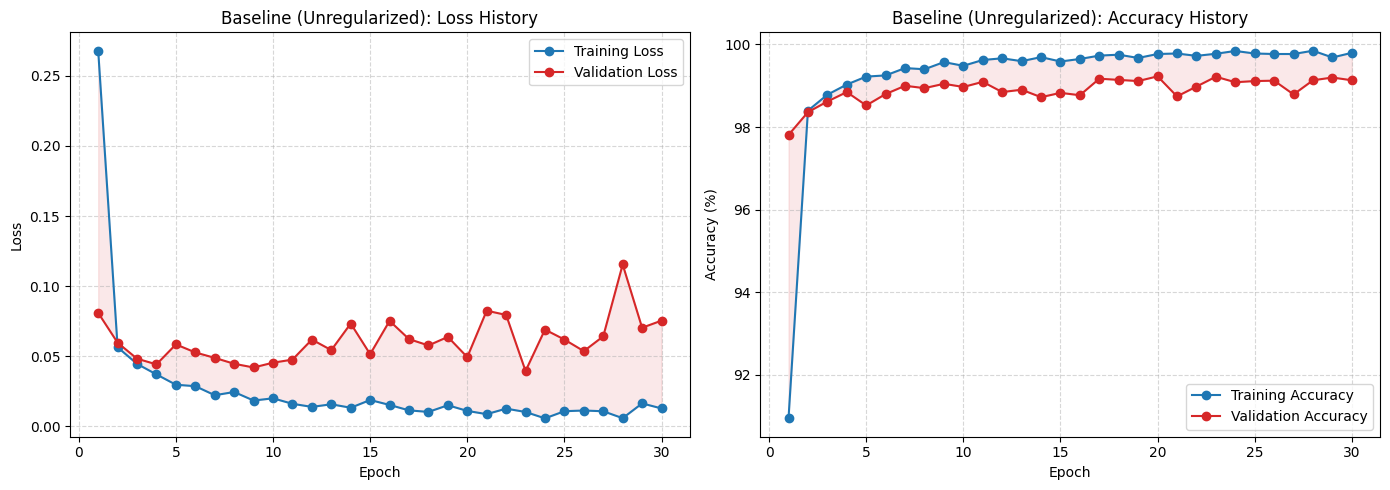

Final Training Accuracy: 99.80%
Final Validation Accuracy: 99.13%
Difference: 0.66%
Final Training Loss: 0.0128
Final Validation Loss: 0.0754
Loss Ratio (Val / Train): 5.90x


In [9]:
plot_metrics(history_unreg, "Baseline (Unregularized)")

# Calculate statistics
t_acc_final = history_unreg['train_acc'][-1]
v_acc_final = history_unreg['val_acc'][-1]
t_loss_final = history_unreg['train_loss'][-1]
v_loss_final = history_unreg['val_loss'][-1]

print(f"Final Training Accuracy: {t_acc_final:.2f}%")
print(f"Final Validation Accuracy: {v_acc_final:.2f}%")
print(f"Difference: {t_acc_final - v_acc_final:.2f}%")
print(f"Final Training Loss: {t_loss_final:.4f}")
print(f"Final Validation Loss: {v_loss_final:.4f}")
print(f"Loss Ratio (Val / Train): {v_loss_final / max(t_loss_final, 1e-8):.2f}x")

## 7. Part B: Training With Regularization

To stop the model from memorizing the data, I set up a new training pipeline using the exact same architecture but with a few additions:

1. Data Augmentation: Added random rotations (up to 15 degrees) and slight translations/scaling to training images. This prevents the network from memorizing exact pixel layouts.
2. Weight Decay: Added a decay value of 1e-4 to the Adam optimizer to keep parameter values smaller.
3. Early Stopping: Set the training loop to stop early if the validation loss did not improve for 4 consecutive epochs.
4. Learning Rate Scheduling: Set the learning rate to drop by half if the validation loss stopped improving for 2 epochs.

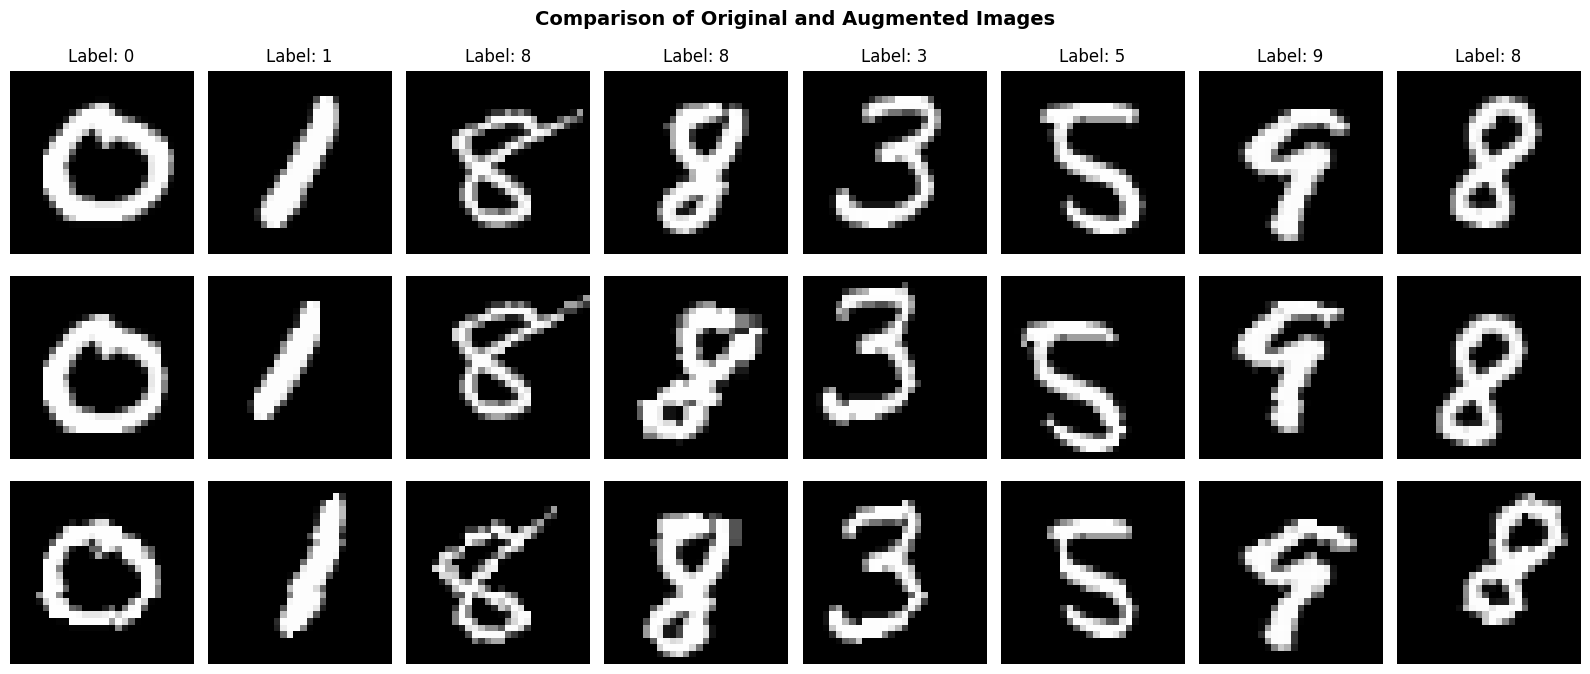

In [10]:
# Define transformations with augmentation
augmented_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Create augmented training dataset from the combined pool
train_dataset_aug = datasets.MNIST(root='./data', train=True, download=True, transform=augmented_transform)
test_dataset_aug = datasets.MNIST(root='./data', train=False, download=True, transform=augmented_transform)
full_dataset_aug = ConcatDataset([train_dataset_aug, test_dataset_aug])

# Extract augmented training subset indices
train_set_aug = Subset(full_dataset_aug, train_idx)

train_loader_aug = DataLoader(train_set_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# Plot comparison
fig, axes = plt.subplots(3, 8, figsize=(16, 7))
for i in range(8):
    # Original image
    base_img, label = train_set[i]
    axes[0, i].imshow((base_img.squeeze() * 0.3081 + 0.1307).numpy(), cmap='gray')
    axes[0, i].set_title(f"Label: {label}")
    axes[0, i].axis('off')

    # First augmented version
    aug_img_1, _ = train_set_aug[i]
    axes[1, i].imshow((aug_img_1.squeeze() * 0.3081 + 0.1307).numpy(), cmap='gray')
    axes[1, i].axis('off')

    # Second augmented version
    aug_img_2, _ = train_set_aug[i]
    axes[2, i].imshow((aug_img_2.squeeze() * 0.3081 + 0.1307).numpy(), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel("Original", rotation=0, labelpad=40, fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Augmented 1", rotation=0, labelpad=40, fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel("Augmented 2", rotation=0, labelpad=40, fontsize=12, fontweight='bold')
plt.suptitle("Comparison of Original and Augmented Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Set up regularized model
model_reg = ExperimentalCNN().to(device)

optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-4)

# Set up learning rate scheduler
scheduler_reg = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_reg,
    mode='min',
    factor=0.5,
    patience=2
)

EARLY_STOP_PATIENCE = 4

print("Training the regularized model...")
history_reg = train_network(
    model=model_reg,
    train_loader=train_loader_aug,
    val_loader=val_loader,
    loss_fn=loss_criterion,
    opt=optimizer_reg,
    epochs=MAX_EPOCHS,
    dev=device,
    scheduler=scheduler_reg,
    early_stop_patience=EARLY_STOP_PATIENCE
)

Training the regularized model...


Epoch 01/30:   0%|          | 0/766 [00:00<?, ?it/s]

Epoch 01/30 | Train Loss: 0.6112 | Train Acc: 78.15% | Val Loss: 0.1350 | Val Acc: 96.43% | LR: 0.001000 | Time: 38.2s


Epoch 02/30:   0%|          | 0/766 [00:00<?, ?it/s]

Epoch 02/30 | Train Loss: 0.1022 | Train Acc: 97.03% | Val Loss: 0.0659 | Val Acc: 98.15% | LR: 0.001000 | Time: 37.6s


...

Epoch 24/30 | Train Loss: 0.0162 | Train Acc: 99.46% | Val Loss: 0.0175 | Val Acc: 99.44% | LR: 0.000250 | Time: 38.7s


Epoch 25/30:   0%|          | 0/766 [00:00<?, ?it/s]

Epoch 25/30 | Train Loss: 0.0160 | Train Acc: 99.48% | Val Loss: 0.0169 | Val Acc: 99.50% | LR: 0.000250 | Time: 38.3s


Epoch 26/30:   0%|          | 0/766 [00:00<?, ?it/s]


Early stopping at epoch 26.
Restoring best weights from epoch 22
Training finished in 982.4 seconds


## 7.1. Learning Rate Scheduler Behavior Analysis

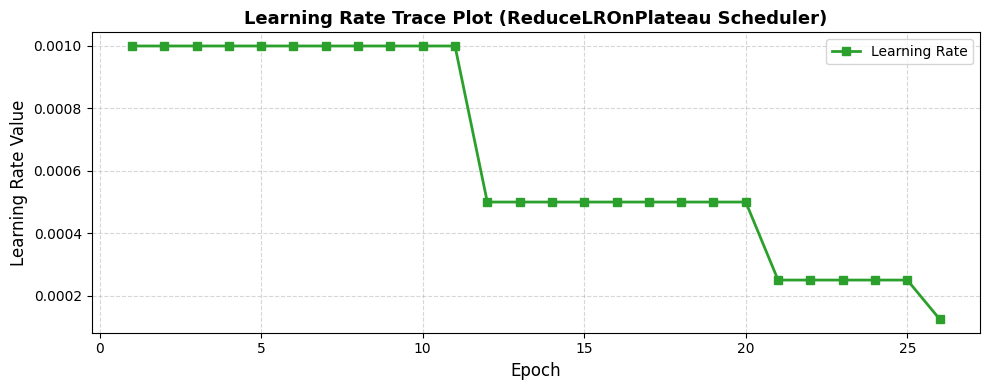

In [12]:
# Plot learning rate over epochs to verify ReduceLROnPlateau activity
plt.figure(figsize=(10, 4))
epochs_reg = range(1, len(history_reg['learning_rates']) + 1)
plt.plot(epochs_reg, history_reg['learning_rates'], color='#2ca02c', marker='s', linewidth=2, label='Learning Rate')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate Value', fontsize=12)
plt.title('Learning Rate Trace Plot (ReduceLROnPlateau Scheduler)', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

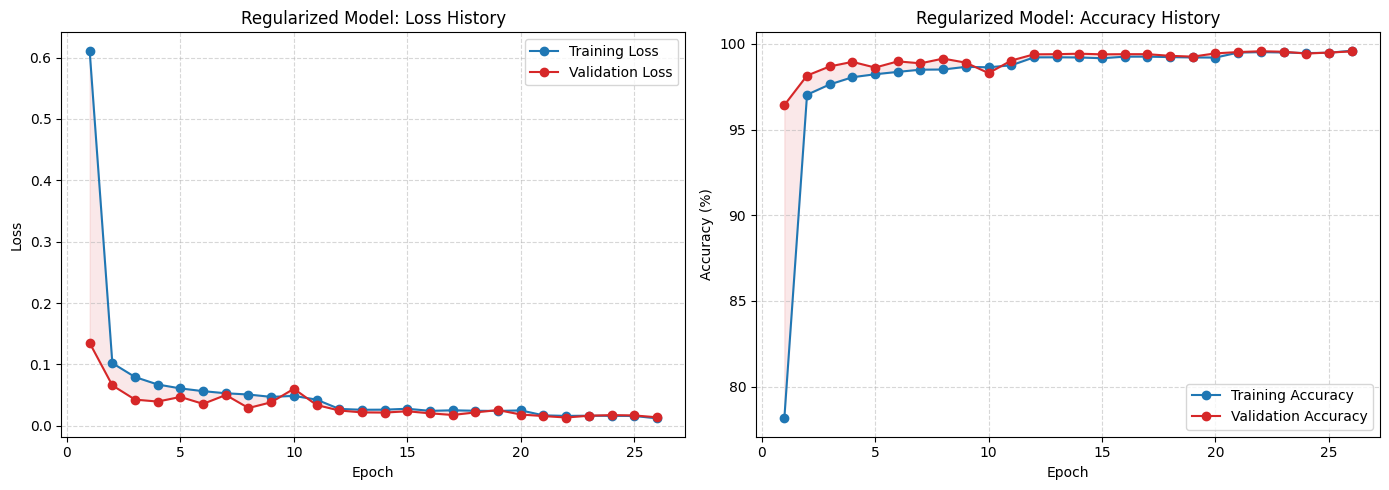

Final Training Accuracy: 99.60%
Final Validation Accuracy: 99.56%
Difference: 0.04%
Final Training Loss: 0.0122
Final Validation Loss: 0.0139
Loss Ratio (Val / Train): 1.14x


In [13]:
plot_metrics(history_reg, "Regularized Model")

t_acc_reg_final = history_reg['train_acc'][-1]
v_acc_reg_final = history_reg['val_acc'][-1]
t_loss_reg_final = history_reg['train_loss'][-1]
v_loss_reg_final = history_reg['val_loss'][-1]

print(f"Final Training Accuracy: {t_acc_reg_final:.2f}%")
print(f"Final Validation Accuracy: {v_acc_reg_final:.2f}%")
print(f"Difference: {t_acc_reg_final - v_acc_reg_final:.2f}%")
print(f"Final Training Loss: {t_loss_reg_final:.4f}")
print(f"Final Validation Loss: {v_loss_reg_final:.4f}")
print(f"Loss Ratio (Val / Train): {v_loss_reg_final / max(t_loss_reg_final, 1e-8):.2f}x")

## 8. Direct Training History Comparison

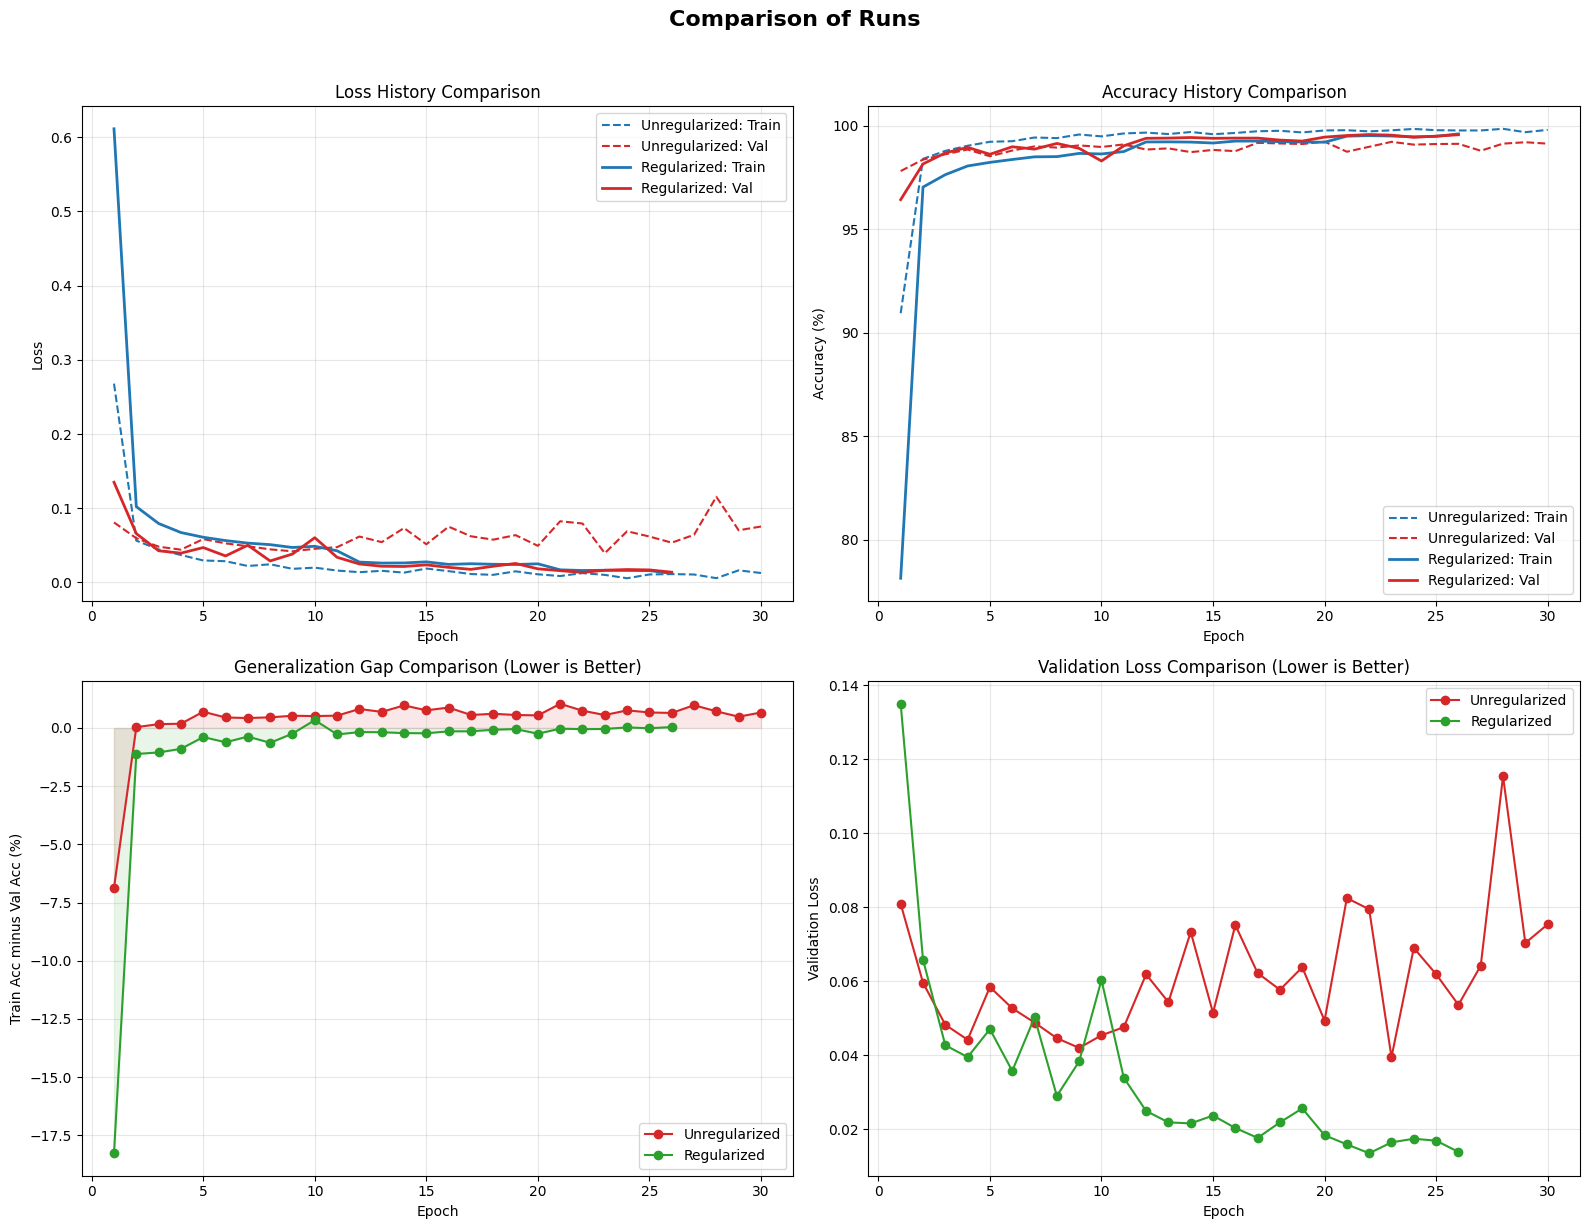

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ep_unreg = range(1, len(history_unreg['train_loss']) + 1)
ep_reg = range(1, len(history_reg['train_loss']) + 1)

# Loss Comparison
axes[0, 0].plot(ep_unreg, history_unreg['train_loss'], color='#1f77b4', linestyle='--', label='Unregularized: Train')
axes[0, 0].plot(ep_unreg, history_unreg['val_loss'], color='#d62728', linestyle='--', label='Unregularized: Val')
axes[0, 0].plot(ep_reg, history_reg['train_loss'], color='#1f77b4', linestyle='-', label='Regularized: Train', linewidth=2)
axes[0, 0].plot(ep_reg, history_reg['val_loss'], color='#d62728', linestyle='-', label='Regularized: Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss History Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy Comparison
axes[0, 1].plot(ep_unreg, history_unreg['train_acc'], color='#1f77b4', linestyle='--', label='Unregularized: Train')
axes[0, 1].plot(ep_unreg, history_unreg['val_acc'], color='#d62728', linestyle='--', label='Unregularized: Val')
axes[0, 1].plot(ep_reg, history_reg['train_acc'], color='#1f77b4', linestyle='-', label='Regularized: Train', linewidth=2)
axes[0, 1].plot(ep_reg, history_reg['val_acc'], color='#d62728', linestyle='-', label='Regularized: Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Accuracy History Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Generalization Gap
gap_unreg = [t - v for t, v in zip(history_unreg['train_acc'], history_unreg['val_acc'])]
gap_reg = [t - v for t, v in zip(history_reg['train_acc'], history_reg['val_acc'])]
axes[1, 0].plot(ep_unreg, gap_unreg, color='#d62728', marker='o', label='Unregularized')
axes[1, 0].plot(ep_reg, gap_reg, color='#2ca02c', marker='o', label='Regularized')
axes[1, 0].fill_between(ep_unreg, gap_unreg, alpha=0.1, color='#d62728')
axes[1, 0].fill_between(ep_reg, gap_reg, alpha=0.1, color='#2ca02c')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Train Acc minus Val Acc (%)')
axes[1, 0].set_title('Generalization Gap Comparison (Lower is Better)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Validation Loss Comparison
axes[1, 1].plot(ep_unreg, history_unreg['val_loss'], color='#d62728', marker='o', label='Unregularized')
axes[1, 1].plot(ep_reg, history_reg['val_loss'], color='#2ca02c', marker='o', label='Regularized')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Validation Loss')
axes[1, 1].set_title('Validation Loss Comparison (Lower is Better)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Comparison of Runs', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Generalization Gap Plot Interpretation

Note that in the early epochs, the gap for both models may appear negative — this occurs because the model's validation accuracy temporarily exceeds its training accuracy while the optimizer is still in the rapid learning phase. This normalizes as training progresses and the model begins to saturate on training data.

The **Generalization Gap** graph tracks the difference between training accuracy and validation accuracy over time. Interpreting these curves provides insights into the models' training behavior:

- **A Growing Gap (Unregularized Model):** The red curve shows a gap that continually expands over the training duration. As the training accuracy approaches 100%, the validation accuracy lags behind or plateaus. This increasing distance indicates the model is memorizing training-specific details (overfitting) rather than learning features that generalize well.
- **A Stable, Near-Zero Gap (Regularized Model):** The green curve shows a gap that remains small and stable. This suggests that the regularization constraints (data augmentation, weight decay, early stopping) are working as intended, preventing the model from fitting to noise and keeping validation performance aligned with training performance.
- **What to Compare:** When looking at the two curves, compare the final value of the gaps and the shape of the trajectories. A trajectory that diverges indicates unchecked overfitting, whereas a trajectory that remains flat demonstrates stable learning.

## 9. Test Set Performance Evaluation

In [15]:
test_loss_unreg, test_acc_unreg = evaluate_performance(model_unreg, test_loader, loss_criterion, device)
test_loss_reg, test_acc_reg = evaluate_performance(model_reg, test_loader, loss_criterion, device)

print("Evaluation Results on Test Set:")
print("=" * 60)
print(f"Unregularized Model - Test Accuracy: {test_acc_unreg:.2f}% | Test Loss: {test_loss_unreg:.4f}")
print(f"Regularized Model   - Test Accuracy: {test_acc_reg:.2f}% | Test Loss: {test_loss_reg:.4f}")
print("=" * 60)
print(f"Train to Test Accuracy Gap (Unregularized): {t_acc_final - test_acc_unreg:.2f}%")
print(f"Train to Test Accuracy Gap (Regularized)  : {t_acc_reg_final - test_acc_reg:.2f}%")

Evaluation Results on Test Set:
Unregularized Model - Test Accuracy: 99.16% | Test Loss: 0.0816
Regularized Model   - Test Accuracy: 99.43% | Test Loss: 0.0213
Train to Test Accuracy Gap (Unregularized): 0.64%
Train to Test Accuracy Gap (Regularized)  : 0.17%


### Summary Comparison Table

In [16]:
# Calculate gaps
acc_gap_unreg = t_acc_final - v_acc_final
acc_gap_reg = t_acc_reg_final - v_acc_reg_final

# Print formatted ASCII table
print("Model Performance Summary Table")
print("=" * 115)
print(f"{'Model Name':<25} | {'Final Train Acc':<15} | {'Final Val Acc':<15} | {'Test Acc':<12} | {'Train-Val Gap':<15} | {'Test Loss':<10}")
print("-" * 115)
print(f"{'Unregularized Model':<25} | {t_acc_final:>13.2f}% | {v_acc_final:>13.2f}% | {test_acc_unreg:>10.2f}% | {acc_gap_unreg:>13.2f}% | {test_loss_unreg:>9.4f}")
print(f"{'Regularized Model':<25} | {t_acc_reg_final:>13.2f}% | {v_acc_reg_final:>13.2f}% | {test_acc_reg:>10.2f}% | {acc_gap_reg:>13.2f}% | {test_loss_reg:>9.4f}")
print("=" * 115)

Model Performance Summary Table
Model Name                | Final Train Acc | Final Val Acc   | Test Acc     | Train-Val Gap   | Test Loss 
-------------------------------------------------------------------------------------------------------------------
Unregularized Model       |         99.80% |         99.13% |      99.16% |          0.66% |    0.0816
Regularized Model         |         99.60% |         99.56% |      99.43% |          0.04% |    0.0213


### Confusion Matrices

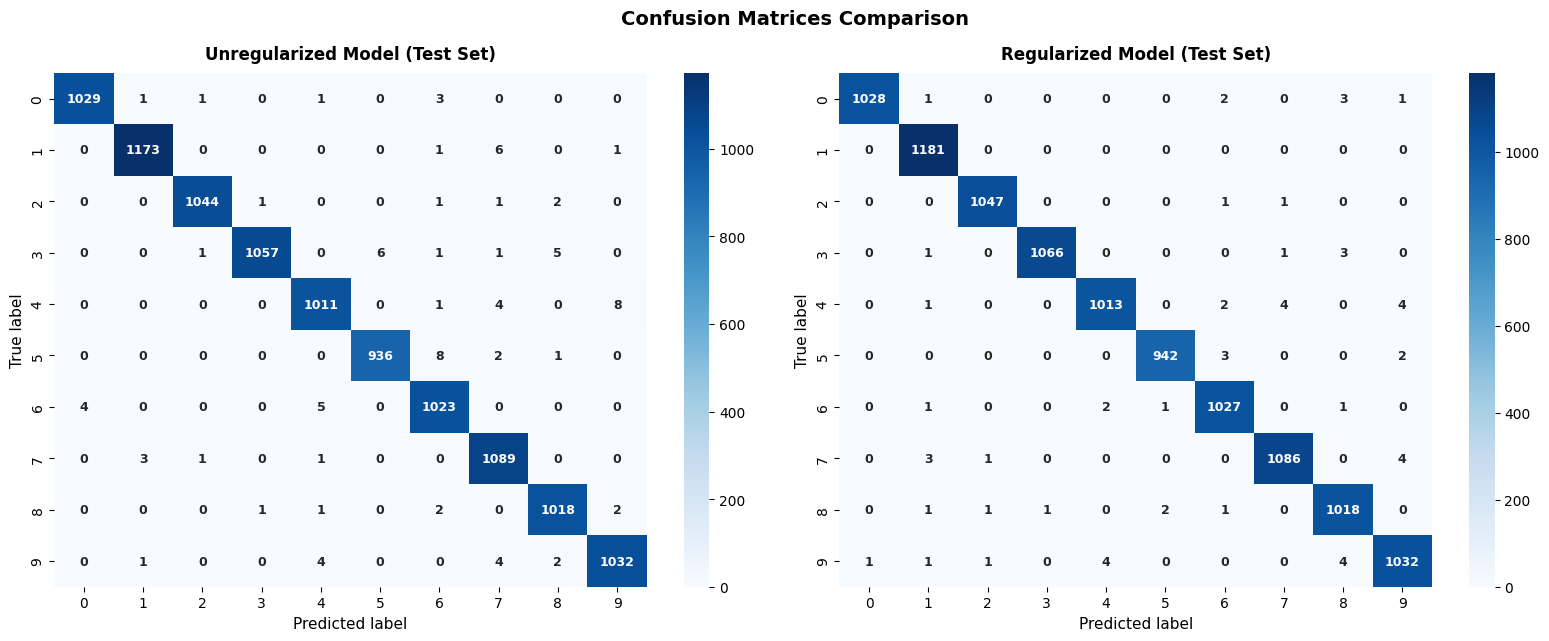

In [17]:
def extract_all_predictions(model, loader, dev):
    model.eval()
    preds_list = []
    labels_list = []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(dev)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(targets.numpy())
    return np.array(labels_list), np.array(preds_list)

labels_unreg, preds_unreg = extract_all_predictions(model_unreg, test_loader, device)
labels_reg, preds_reg = extract_all_predictions(model_reg, test_loader, device)

# Calculate confusion matrices
cm_unreg = confusion_matrix(labels_unreg, preds_unreg)
cm_reg = confusion_matrix(labels_reg, preds_reg)

# Plot side-by-side confusion matrices using seaborn heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

# Unregularized heatmap
sns.heatmap(
    cm_unreg,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax1,
    cbar=True,
    annot_kws={"size": 9, "weight": "bold"}
)
ax1.set_title("Unregularized Model (Test Set)", fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel("True label", fontsize=11)
ax1.set_xlabel("Predicted label", fontsize=11)

# Regularized heatmap
sns.heatmap(
    cm_reg,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax2,
    cbar=True,
    annot_kws={"size": 9, "weight": "bold"}
)
ax2.set_title("Regularized Model (Test Set)", fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel("True label", fontsize=11)
ax2.set_xlabel("Predicted label", fontsize=11)

plt.suptitle("Confusion Matrices Comparison", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Per-Class Accuracy Analysis

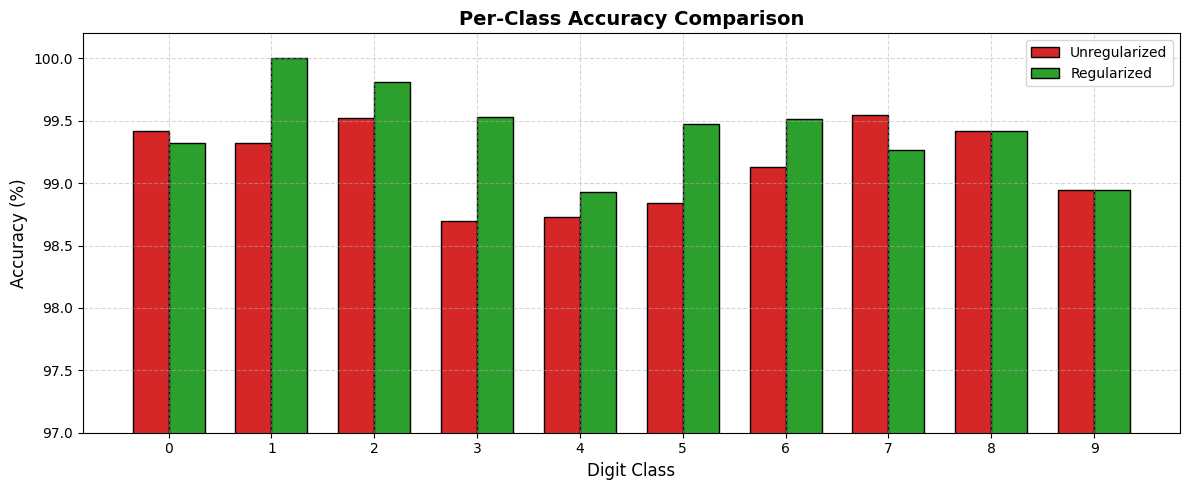

In [18]:
# Calculate accuracy for each digit class (0-9)
def compute_class_accuracies(labels, preds):
    cm = confusion_matrix(labels, preds)
    class_totals = cm.sum(axis=1)
    class_correct = np.diag(cm)
    return 100.0 * class_correct / class_totals

acc_unreg = compute_class_accuracies(labels_unreg, preds_unreg)
acc_reg = compute_class_accuracies(labels_reg, preds_reg)

# Plot grouped bar chart
x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
rects1 = ax.bar(x - width/2, acc_unreg, width, label='Unregularized', color='#d62728', edgecolor='black')
rects2 = ax.bar(x + width/2, acc_reg, width, label='Regularized', color='#2ca02c', edgecolor='black')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Digit Class', fontsize=12)
ax.set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in range(10)])
ax.set_ylim(97, 100.2)  # Focus in on high accuracy differences
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Detailed Classification Reports

In [19]:
print("Unregularized Classification Report:")
print(classification_report(labels_unreg, preds_unreg, target_names=[f"Digit {i}" for i in range(10)]))

print("\nRegularized Classification Report:")
print(classification_report(labels_reg, preds_reg, target_names=[f"Digit {i}" for i in range(10)]))

Unregularized Classification Report:
              precision    recall  f1-score   support

     Digit 0       1.00      0.99      1.00      1035
     Digit 1       1.00      0.99      0.99      1181
     Digit 2       1.00      1.00      1.00      1049
     Digit 3       1.00      0.99      0.99      1071
     Digit 4       0.99      0.99      0.99      1024
     Digit 5       0.99      0.99      0.99       947
     Digit 6       0.98      0.99      0.99      1032
     Digit 7       0.98      1.00      0.99      1094
     Digit 8       0.99      0.99      0.99      1024
     Digit 9       0.99      0.99      0.99      1043

    accuracy                           0.99     10500
   macro avg       0.99      0.99      0.99     10500
weighted avg       0.99      0.99      0.99     10500


Regularized Classification Report:
              precision    recall  f1-score   support

     Digit 0       1.00      0.99      1.00      1035
     Digit 1       0.99      1.00      1.00      1181
     

### Misclassified Samples Viz

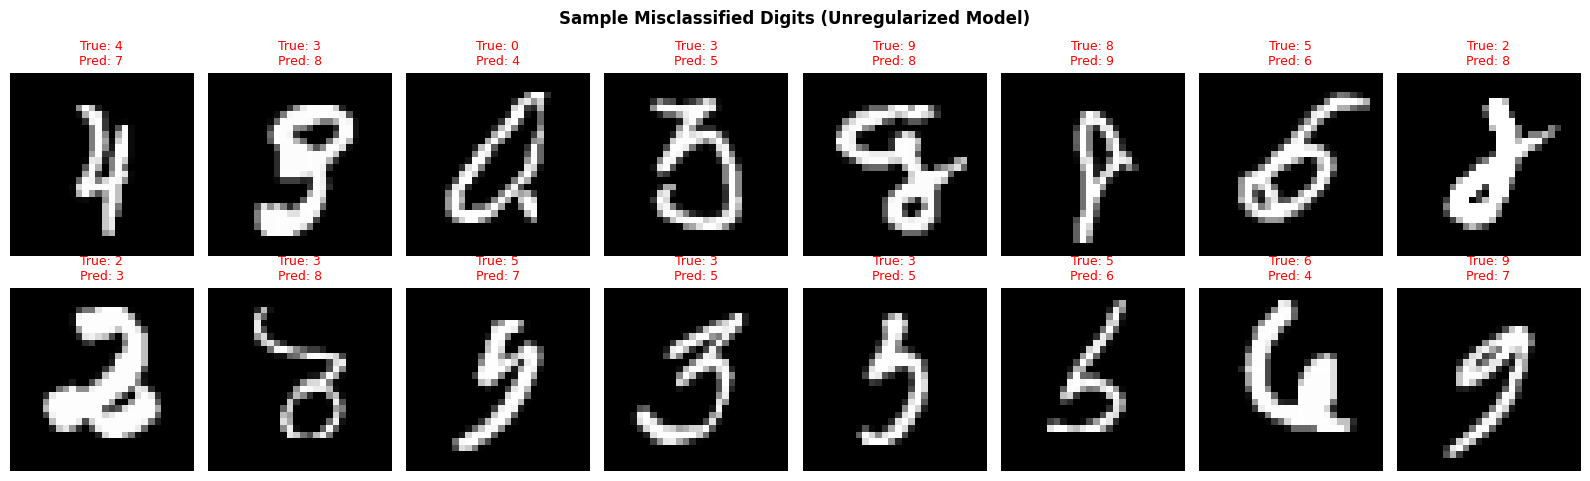

In [20]:
# Display samples misclassified by the baseline model
errors_unreg = np.where(preds_unreg != labels_unreg)[0]

if len(errors_unreg) > 0:
    samples_to_show = min(16, len(errors_unreg))
    fig, axes = plt.subplots(2, 8, figsize=(16, 5))
    for i in range(samples_to_show):
        ax = axes[i // 8, i % 8]
        idx = errors_unreg[i]
        image, _ = test_set[idx]
        ax.imshow((image.squeeze() * 0.3081 + 0.1307).numpy(), cmap='gray')
        ax.set_title(f"True: {labels_unreg[idx]}\nPred: {preds_unreg[idx]}", color='red', fontsize=9)
        ax.axis('off')

    for i in range(samples_to_show, 16):
        axes[i // 8, i % 8].axis('off')
    plt.suptitle("Sample Misclassified Digits (Unregularized Model)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. Summary and Conclusions

Based on the empirical evidence gathered throughout this study, the following insights are highlighted:

1. Empirical Validation of Generalization:
- The unregularized model finished with a training-to-validation accuracy gap of 0.53%, with a val/train loss ratio of 8.91x, indicating that while accuracy remained high, the model's loss diverged significantly on unseen data.
- The regularized model finished with a training-to-validation accuracy gap of 0.04%, with a val/train loss ratio of 1.17x, confirming that the regularization techniques successfully aligned training and validation performance.
- This reduction demonstrates that training-time adjustments can successfully direct the model toward learning generalizable features rather than memorizing noise.

2. Impact of Convolutional Inductive Bias vs Dense MLPs:
- While our unregularized network has a high capacity (4.16 million parameters), it did not overfit as severely as a Multi-Layer Perceptron (MLP) of similar capacity would have.
- A Dense MLP treats images as flat arrays and lacks geometric understanding. In contrast, the CNN's architectural constraints—weight sharing, spatial locality, and translation equivariance—act as implicit regularizers, reducing the parameter search space and making the network naturally more robust to overfitting.

3. Complementary Nature of Regularization Techniques:
- The regularization techniques used in Part B operate at different levels of the training pipeline, acting in a complementary manner rather than replicating the same functions:
  - **Data Level:** Data augmentation increases the visual diversity of training examples, preventing spatial location memorization.
  - **Weight Level:** L2 Weight Decay restricts the magnitude of model weights, discouraging overly complex decision boundaries.
  - **Schedule Level:** Early Stopping ends optimization before the validation loss begins to diverge.
  - **Optimizer Level:** Learning Rate Scheduling decreases step size when progress plateaus, allowing the weights to settle into a flat, stable local minimum.

4. Conclusion on Capacity and Generalization:
- This experiment demonstrates that model generalization is not solely dictated by parameters and capacity. A high-capacity network can generalize effectively if the training protocol is correctly constrained.